In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette (domain-appropriate names) ─────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3147',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2e3147',
    'grid.linewidth':   0.5,
    'font.family':      'DejaVu Sans',
})
 
ACCENT    = '#58a6ff'   # general / neutral
MALIGNANT = '#f85149'   # malignant class  (anomaly)
BENIGN    = '#3fb950'   # benign class     (normal)
WARN      = '#d29922'   # threshold / warning markers
PURPLE    = '#bc8cff'   # secondary accent
 
PALETTE = [ACCENT, MALIGNANT, BENIGN, WARN, PURPLE,
           '#79c0ff', '#ff7b72', '#56d364', '#e3b341', '#d2a8ff']
various_colors = LinearSegmentedColormap.from_list('various', PALETTE, N=10)
# Load the Breast Cancer dataset (replace 'data.csv' with your dataset file)
df = pd.read_csv('breast-cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [26]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [27]:
df.isna().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [28]:
# Patient ID carries no clinical predictive value
df.drop('id', axis=1, inplace=True)

In [29]:
# Encode: Benign (B) → 0, Malignant (M) → 1
label_encoder = LabelEncoder()
df['diagnosis'] = label_encoder.fit_transform(df['diagnosis'])
print("Encoded 'diagnosis' column:")
print(df['diagnosis'].value_counts())


Encoded 'diagnosis' column:
diagnosis
0    357
1    212
Name: count, dtype: int64


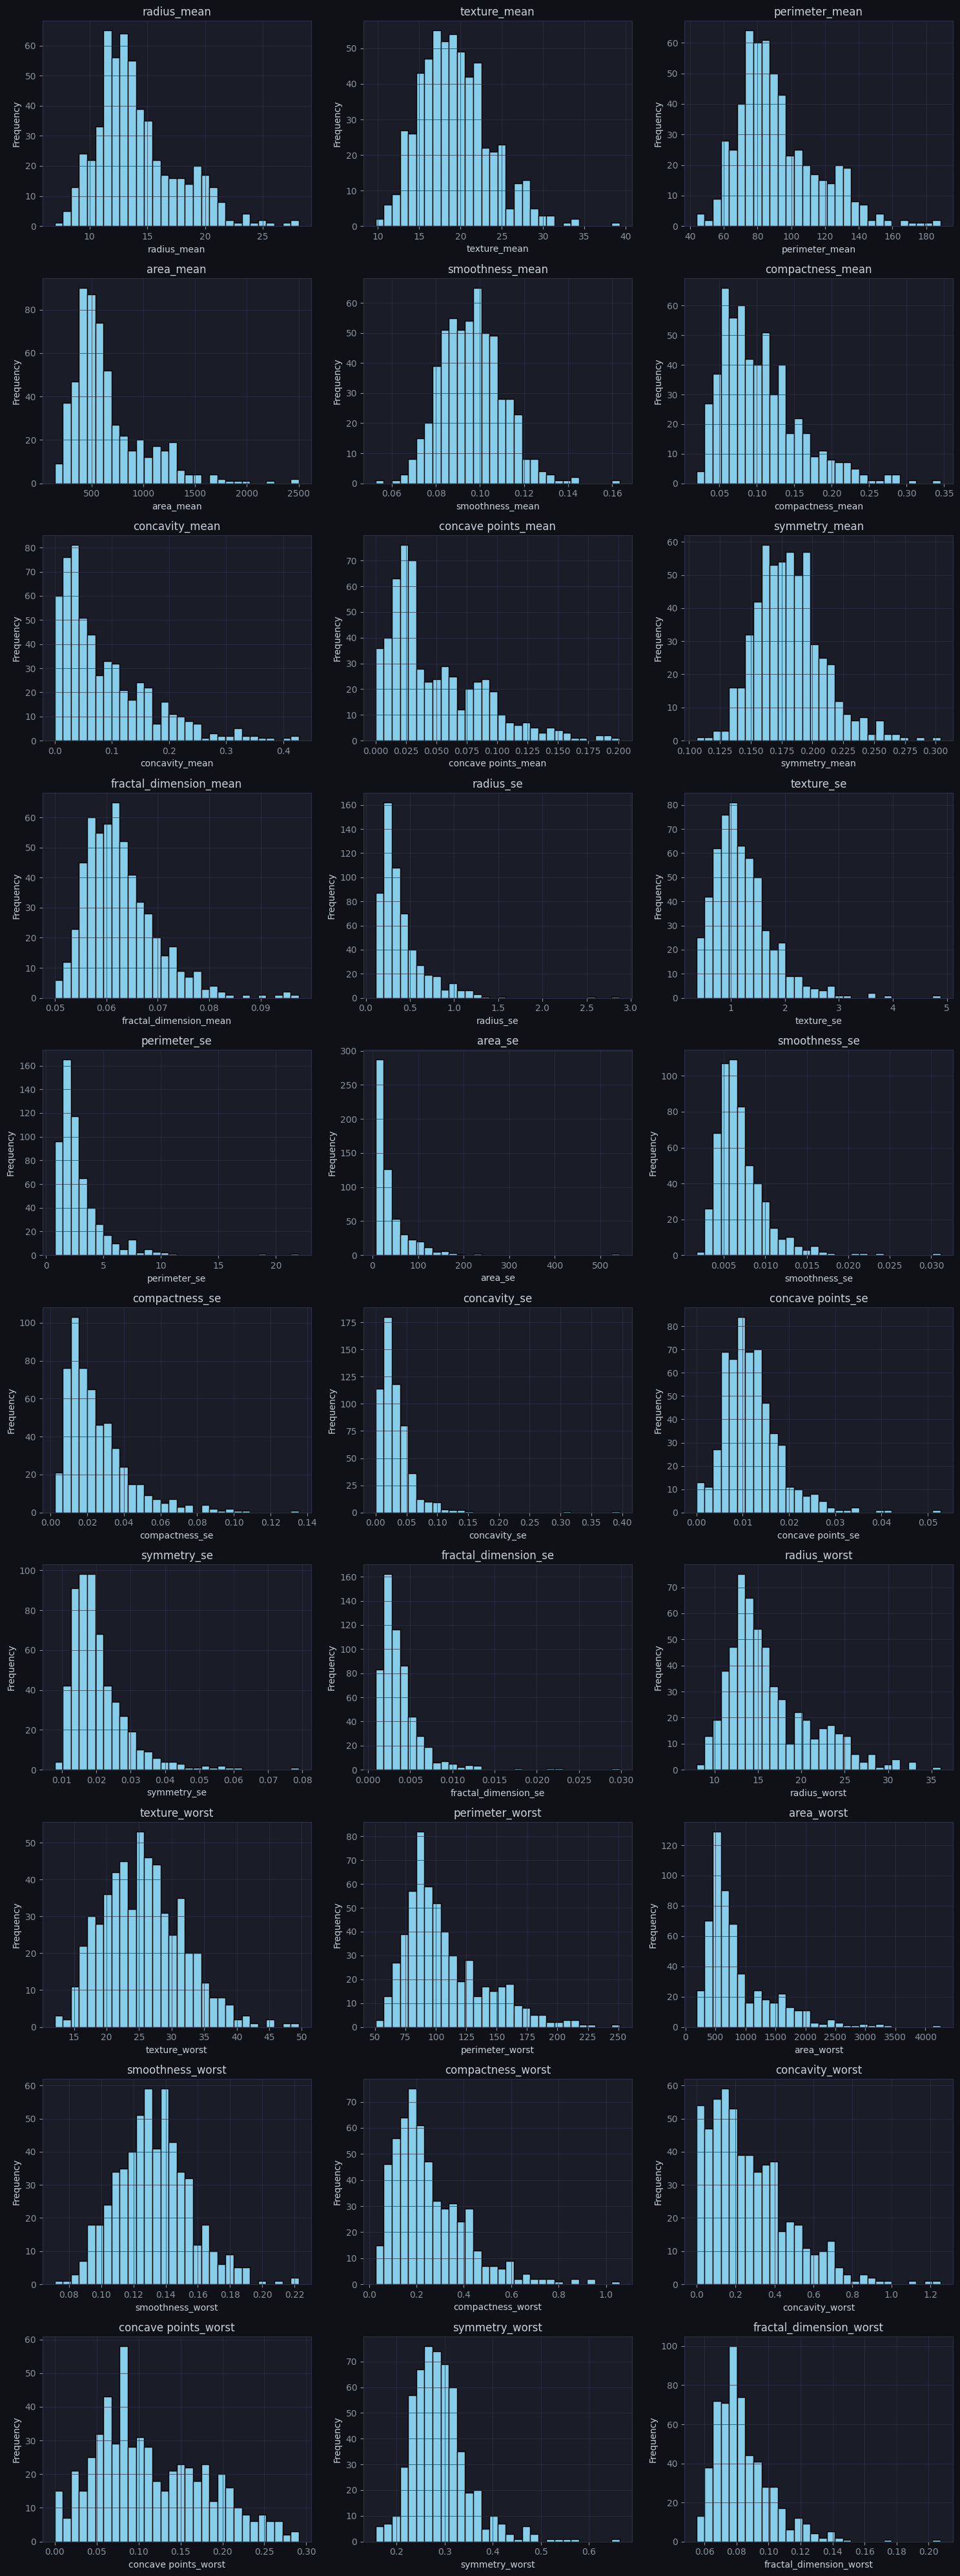

In [30]:
#feature distribution
features = df.columns[1:]  # Exclude 'diagnosis'
num_features = len(features)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols
plt.figure(figsize=(15, num_rows * 4))
for i, feature in enumerate(features):
    plt.subplot(num_rows, num_cols, i + 1)
    df[feature].hist(bins=30, color='skyblue', edgecolor='black')
    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

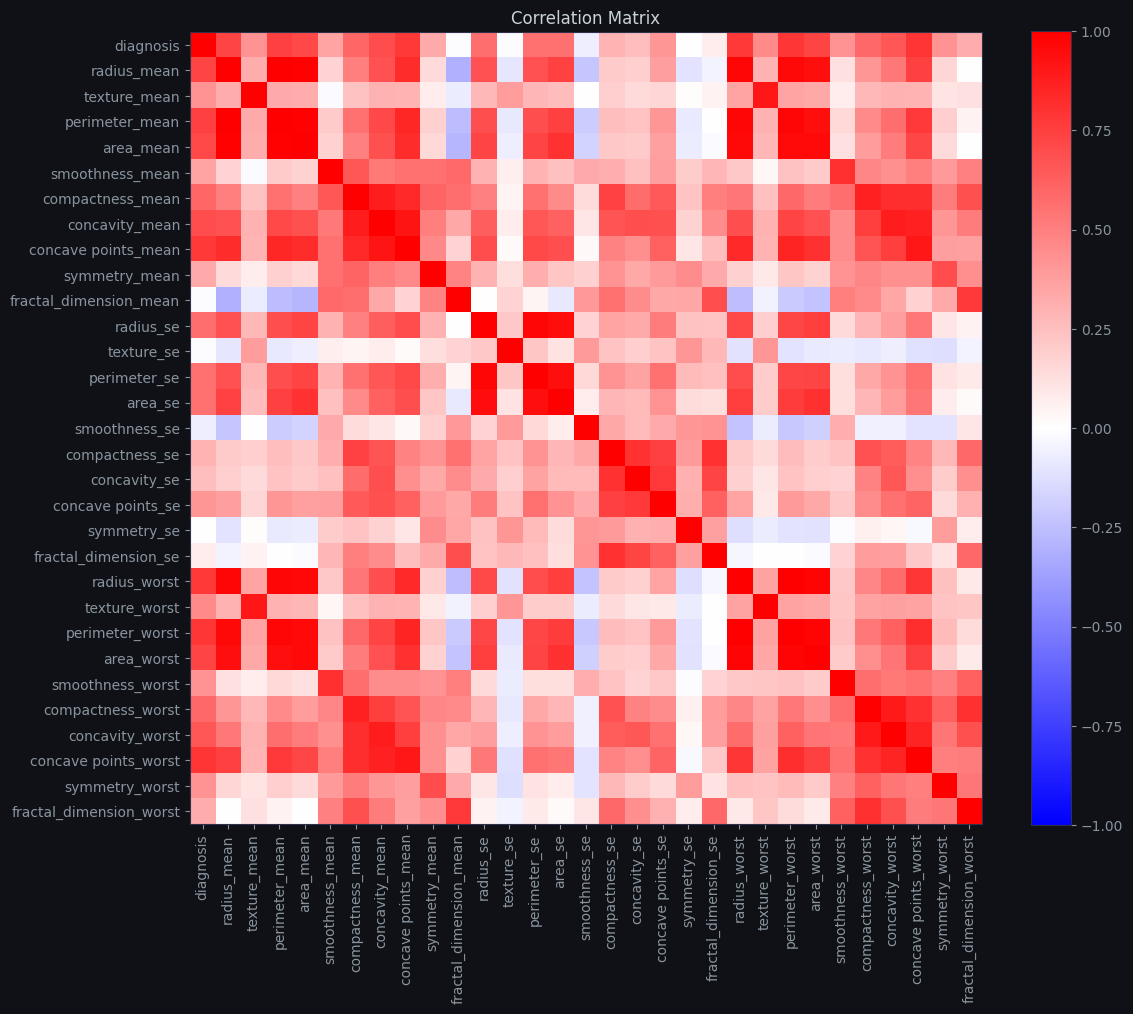

In [31]:
#correlation analysis
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
cmap = LinearSegmentedColormap.from_list('custom_cmap', ['blue', 'white', 'red'])
plt.imshow(correlation_matrix, cmap=cmap, vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [32]:
#top 15 features correlation with diagnosis
correlation_with_target = correlation_matrix['diagnosis'].abs().sort_values(ascending=False)
top_features = correlation_with_target[1:16].index  # Exclude 'diagnosis' itself
print("Top 15 features most correlated with 'diagnosis':")
print(top_features)


Top 15 features most correlated with 'diagnosis':
Index(['concave points_worst', 'perimeter_worst', 'concave points_mean',
       'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean',
       'area_mean', 'concavity_mean', 'concavity_worst', 'compactness_mean',
       'compactness_worst', 'radius_se', 'perimeter_se', 'area_se'],
      dtype='object')


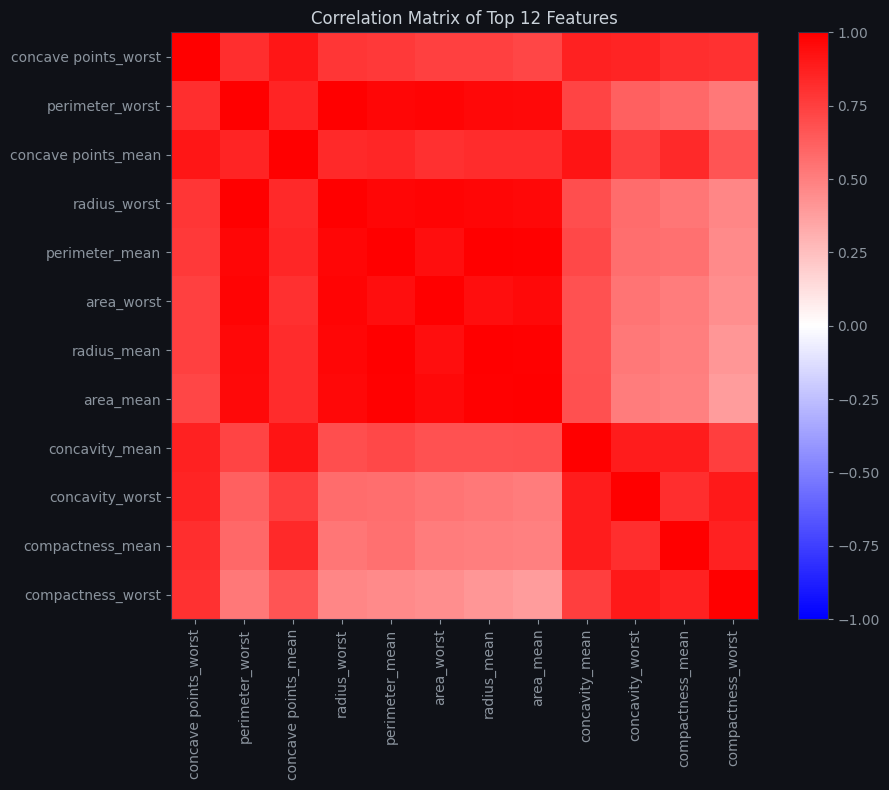

In [33]:
#heatmat for top 12 inter-feature correlation
plt.figure(figsize=(10, 8))
top_12_features = top_features[:12]
top_12_correlation_matrix = df[top_12_features].corr()
plt.imshow(top_12_correlation_matrix, cmap=cmap, vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(top_12_correlation_matrix)), top_12_correlation_matrix.columns, rotation=90)
plt.yticks(range(len(top_12_correlation_matrix)), top_12_correlation_matrix.columns)
plt.title('Correlation Matrix of Top 12 Features')
plt.tight_layout()
plt.show()

In [34]:
#split X and y
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [35]:
# StandardScaler: zero mean, unit variance — prevents large-scale
# features from dominating the isolation tree splits
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

#stratified 80/20 split preserves class distribution in train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


  Selected features (10):
    • radius_mean
    • perimeter_mean
    • area_mean
    • concavity_mean
    • concave points_mean
    • radius_worst
    • texture_worst
    • perimeter_worst
    • area_worst
    • concave points_worst


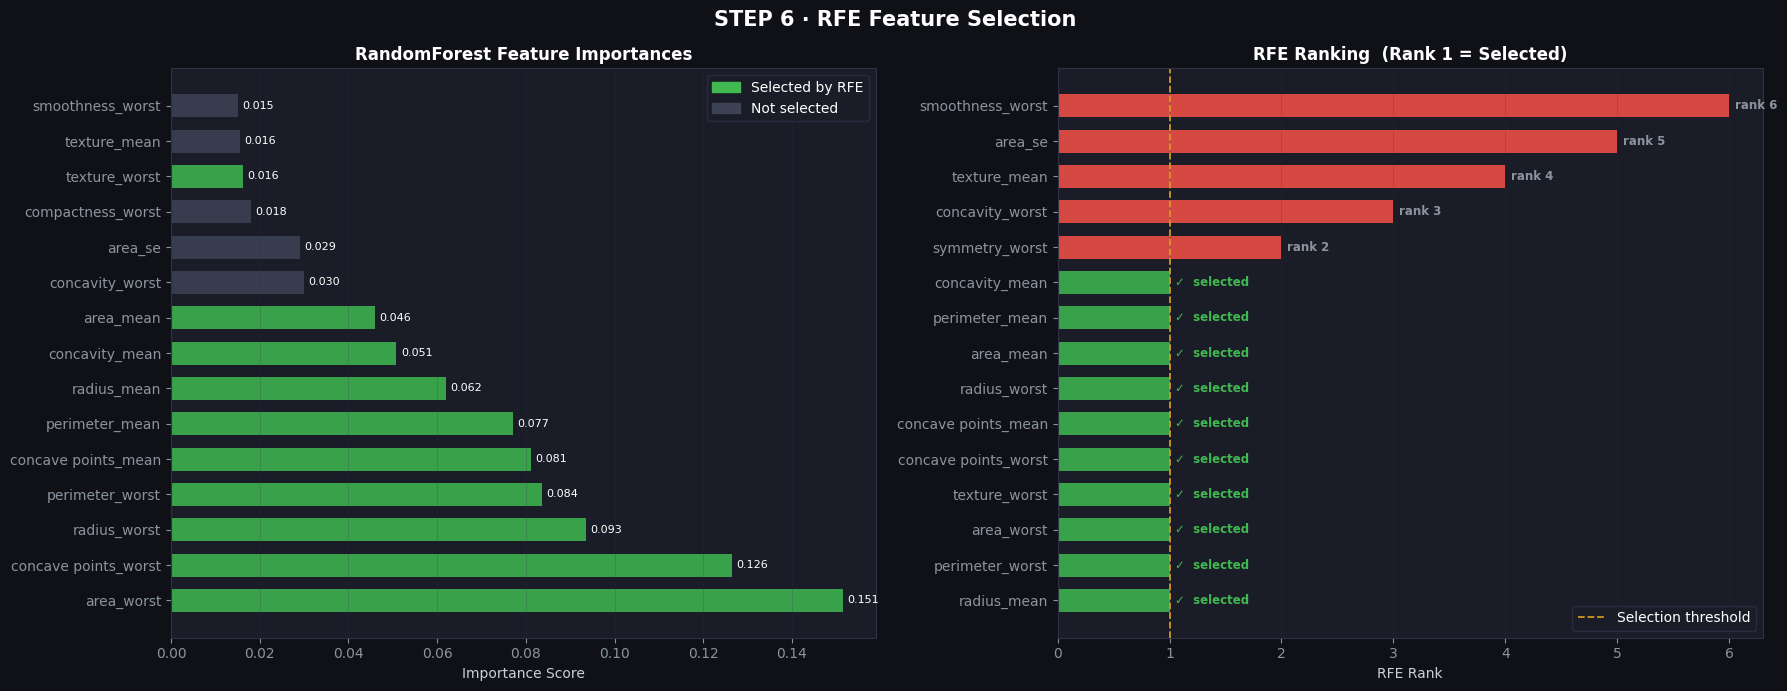

In [36]:
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(rf, n_features_to_select=10)
rfe.fit(X_train, y_train)

selected_features = X_train.columns[rfe.support_].tolist()
rfe_ranking       = pd.Series(rfe.ranking_, index=X_train.columns).sort_values()

# Feature importances for plotting
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_,
                        index=X_train.columns).sort_values(ascending=False)

print(f"  Selected features ({len(selected_features)}):")
for feat in selected_features:
    print(f"    • {feat}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('STEP 6 · RFE Feature Selection',
             fontsize=15, fontweight='bold', color='white')
# Feature importances: selected vs not selected
ax = axes[0]
top_imp    = importances.head(15)
bar_colors = [BENIGN if f in selected_features else '#3d4255'
              for f in top_imp.index]
ax.barh(top_imp.index, top_imp.values,
        color=bar_colors, alpha=0.85, height=0.65)
ax.set_title('RandomForest Feature Importances',
             fontweight='bold', color='white')
ax.set_xlabel('Importance Score')
legend_patches = [
    mpatches.Patch(color=BENIGN,    label='Selected by RFE'),
    mpatches.Patch(color='#3d4255', label='Not selected'),
]
ax.legend(handles=legend_patches, facecolor='#1a1d27',
          edgecolor='#2e3147', labelcolor='white')
for bar, val in zip(ax.patches, top_imp.values):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', color='white', fontsize=8)
ax.grid(axis='x', alpha=0.3)
 
# RFE rankings
ax = axes[1]
rank_top = rfe_ranking.head(15)
ax.barh(rank_top.index, rank_top.values,
        color=[BENIGN if v == 1 else MALIGNANT for v in rank_top.values],
        alpha=0.85, height=0.65)
ax.set_title('RFE Ranking  (Rank 1 = Selected)',
             fontweight='bold', color='white')
ax.set_xlabel('RFE Rank')
ax.axvline(1, color=WARN, linestyle='--', linewidth=1.3,
           label='Selection threshold')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3147', labelcolor='white')
for bar, val in zip(ax.patches, rank_top.values):
    lbl = '✓  selected' if val == 1 else f'rank {val}'
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            lbl, va='center',
            color=BENIGN if val == 1 else '#8b949e',
            fontsize=8.5, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
 
plt.tight_layout()
plt.savefig('bc_step6_rfe.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
plt.close()

 

In [37]:
# ─────────────────────────────────────────────────────────────
# STEP 7 · ISOLATION FOREST — TRAINING (FULLY UNSUPERVISED)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 7 · ISOLATION FOREST TRAINING (FULLY UNSUPERVISED)")
print("=" * 60)
 
X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]
 
# Literature best-practice for anomaly detection:
# Fit ONLY on normal (benign) samples so the model learns
# what healthy tissue looks like, then scores everything.
X_train_benign = X_train_sel[y_train == 0]
print(f"  Training on benign-only samples: {X_train_benign.shape}")
 
# ── Train with contamination='auto' ──────────────────────────
# contamination='auto' sets the decision threshold at score=0
# (the natural boundary of the decision function) rather than
# at a label-derived percentile.  This keeps the model fully
# unsupervised: no knowledge of the anomaly proportion is needed
# or used during training or scoring.
print(f"\n  Training model  (n_estimators=100, contamination='auto') …")
iso = IsolationForest(
    n_estimators=100,      # 100 isolation trees for stable path-length estimates
    contamination='auto',  # threshold at score=0 — no label information used
    max_samples='auto',    # sqrt(n) samples drawn per tree
    max_features=1.0,      # all selected features available at each split
    bootstrap=False,       # sub-sampling without replacement (standard IF)
    random_state=42,
    n_jobs=-1              # parallelise across all CPU cores
)
iso.fit(X_train_benign)
 
# ── Anomaly scores ────────────────────────────────────────────
# decision_function returns: negative = anomalous, positive = normal
# We negate so that HIGHER score = MORE anomalous (more intuitive)
train_scores = -iso.decision_function(X_train_sel)
test_scores  = -iso.decision_function(X_test_sel)
 
# ── Score-distribution-based threshold (Otsu-style) ──────────
# Rather than using a contamination-derived percentile, we find
# the threshold that maximises inter-class variance of the score
# distribution — fully unsupervised, no label leakage.
def otsu_threshold(scores: np.ndarray, n_bins: int = 300) -> float:
    """Return the score threshold that maximises inter-class variance."""
    hist, bin_edges = np.histogram(scores, bins=n_bins)
    bin_centres     = (bin_edges[:-1] + bin_edges[1:]) / 2
    total           = hist.sum()
    best_thresh, best_var = bin_centres[0], 0.0
    w0 = 0.0
    sum0 = 0.0
    total_mean = np.sum(hist * bin_centres) / total
    for i, (count, centre) in enumerate(zip(hist, bin_centres)):
        w0   += count / total
        w1    = 1.0 - w0
        if w0 == 0 or w1 == 0:
            continue
        sum0 += count * centre / total
        mean0 = sum0 / w0
        mean1 = (total_mean - sum0) / w1
        var   = w0 * w1 * (mean0 - mean1) ** 2
        if var > best_var:
            best_var, best_thresh = var, centre
    return best_thresh
 
decision_threshold = otsu_threshold(test_scores)
print(f"  Score-distribution threshold (Otsu): {decision_threshold:.4f}")
print(f"  (Scores above this are classified as malignant)")
 
# Binary predictions derived from the unsupervised threshold
train_pred = (train_scores > otsu_threshold(train_scores)).astype(int)
test_pred  = (test_scores  > decision_threshold).astype(int)
print("  ✓ Model trained and threshold derived without label information")
 


STEP 7 · ISOLATION FOREST TRAINING (FULLY UNSUPERVISED)
  Training on benign-only samples: (285, 10)

  Training model  (n_estimators=100, contamination='auto') …
  Score-distribution threshold (Otsu): 0.0790
  (Scores above this are classified as malignant)
  ✓ Model trained and threshold derived without label information


In [38]:
# ── Anomaly scores ────────────────────────────────────────────
# decision_function returns: negative = anomalous, positive = normal
# We negate so that HIGHER score = MORE anomalous (more intuitive)
train_scores = -iso.decision_function(X_train_sel)
test_scores  = -iso.decision_function(X_test_sel)
 
# ── Score-distribution-based threshold (Otsu-style) ──────────
# Rather than using a contamination-derived percentile, we find
# the threshold that maximises inter-class variance of the score
# distribution — fully unsupervised, no label leakage.
def otsu_threshold(scores: np.ndarray, n_bins: int = 300) -> float:
    """Return the score threshold that maximises inter-class variance."""
    hist, bin_edges = np.histogram(scores, bins=n_bins)
    bin_centres     = (bin_edges[:-1] + bin_edges[1:]) / 2
    total           = hist.sum()
    best_thresh, best_var = bin_centres[0], 0.0
    w0 = 0.0
    sum0 = 0.0
    total_mean = np.sum(hist * bin_centres) / total
    for i, (count, centre) in enumerate(zip(hist, bin_centres)):
        w0   += count / total
        w1    = 1.0 - w0
        if w0 == 0 or w1 == 0:
            continue
        sum0 += count * centre / total
        mean0 = sum0 / w0
        mean1 = (total_mean - sum0) / w1
        var   = w0 * w1 * (mean0 - mean1) ** 2
        if var > best_var:
            best_var, best_thresh = var, centre
    return best_thresh
 
decision_threshold = otsu_threshold(test_scores)
print(f"  Score-distribution threshold (Otsu): {decision_threshold:.4f}")
print(f"  (Scores above this are classified as malignant)")
 
# Binary predictions derived from the unsupervised threshold
train_pred = (train_scores > otsu_threshold(train_scores)).astype(int)
test_pred  = (test_scores  > decision_threshold).astype(int)
print("  ✓ Model trained and threshold derived without label information")

  Score-distribution threshold (Otsu): 0.0790
  (Scores above this are classified as malignant)
  ✓ Model trained and threshold derived without label information


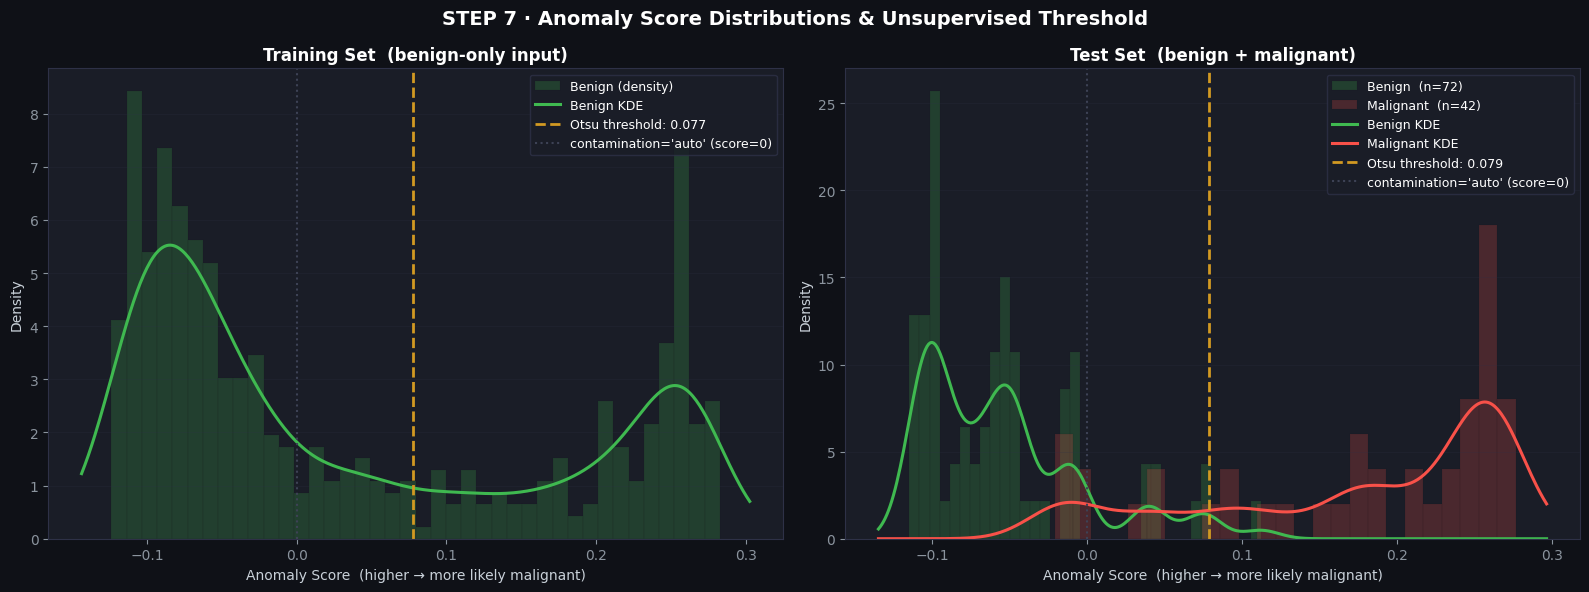

In [39]:
# ── Step 7 visualisation: density + class-separated KDE overlays
from scipy.stats import gaussian_kde
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('STEP 7 · Anomaly Score Distributions & Unsupervised Threshold',
             fontsize=14, fontweight='bold', color='white')
 
# ── Left: training set (benign-only — single KDE) ────────────
ax = axes[0]
thresh_train = otsu_threshold(train_scores)
score_range  = np.linspace(train_scores.min() - 0.02,
                            train_scores.max() + 0.02, 400)
ax.hist(train_scores, bins=40, density=True,
        color=BENIGN, alpha=0.22, edgecolor='#0f1117',
        linewidth=0.3, label='Benign (density)')
kde_ben = gaussian_kde(train_scores, bw_method=0.18)
ax.plot(score_range, kde_ben(score_range),
        color=BENIGN, linewidth=2.2, label='Benign KDE')
ax.axvline(thresh_train, color=WARN, linestyle='--', linewidth=2,
           label=f'Otsu threshold: {thresh_train:.3f}')
ax.axvline(0, color='#3d4255', linestyle=':', linewidth=1.5,
           label="contamination='auto' (score=0)")
ax.set_title('Training Set  (benign-only input)',
             fontweight='bold', color='white')
ax.set_xlabel('Anomaly Score  (higher → more likely malignant)')
ax.set_ylabel('Density')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3147',
          labelcolor='white', fontsize=9)
ax.grid(axis='y', alpha=0.3)
 
# ── Right: test set (benign + malignant — two KDEs) ──────────
ax = axes[1]
thresh_test = otsu_threshold(test_scores)
s_ben = test_scores[y_test.values == 0]
s_mal = test_scores[y_test.values == 1]
score_range = np.linspace(test_scores.min() - 0.02,
                           test_scores.max() + 0.02, 400)
ax.hist(s_ben, bins=35, density=True,
        color=BENIGN, alpha=0.22, edgecolor='#0f1117',
        linewidth=0.3, label=f'Benign  (n={len(s_ben)})')
ax.hist(s_mal, bins=25, density=True,
        color=MALIGNANT, alpha=0.22, edgecolor='#0f1117',
        linewidth=0.3, label=f'Malignant  (n={len(s_mal)})')
kde_b = gaussian_kde(s_ben, bw_method=0.22)
kde_m = gaussian_kde(s_mal, bw_method=0.22)
ax.plot(score_range, kde_b(score_range),
        color=BENIGN,    linewidth=2.2, label='Benign KDE')
ax.plot(score_range, kde_m(score_range),
        color=MALIGNANT, linewidth=2.2, label='Malignant KDE')
ax.axvline(thresh_test, color=WARN, linestyle='--', linewidth=2,
           label=f'Otsu threshold: {thresh_test:.3f}')
ax.axvline(0, color='#3d4255', linestyle=':', linewidth=1.5,
           label="contamination='auto' (score=0)")
ax.set_title('Test Set  (benign + malignant)',
             fontweight='bold', color='white')
ax.set_xlabel('Anomaly Score  (higher → more likely malignant)')
ax.set_ylabel('Density')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3147',
          labelcolor='white', fontsize=9)
ax.grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig('bc_step7_score_dist.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
plt.close()
# print("  ✓ Saved: bc_step7_score_dist.png")

In [40]:
# ─────────────────────────────────────────────────────────────
# STEP 8 · EVALUATION & VISUALIZATIONS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 8 · MODEL EVALUATION")
print("=" * 60)
 
# ── Compute all metrics ──
cm                  = confusion_matrix(y_test, test_pred)
auc                 = roc_auc_score(y_test, test_scores)
ap                  = average_precision_score(y_test, test_scores)
tn, fp, fn, tp      = cm.ravel()
precision_malignant = tp / max(tp + fp, 1)
recall_malignant    = tp / max(tp + fn, 1)
f1_malignant        = (2 * precision_malignant * recall_malignant /
                       max(precision_malignant + recall_malignant, 1e-9))
fpr_curve, tpr_curve, _  = roc_curve(y_test, test_scores)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_scores)
 
print(f"\n  Classification Report:\n")
print(classification_report(y_test, test_pred,
                             target_names=['Benign', 'Malignant']))
print(f"  ROC-AUC                    : {auc:.4f}")
print(f"  Average Precision          : {ap:.4f}")
print(f"  Precision (Malignant)      : {precision_malignant:.4f}")
print(f"  Recall    (Malignant)      : {recall_malignant:.4f}")
print(f"  F1 Score  (Malignant)      : {f1_malignant:.4f}")
print(f"\n  Confusion Matrix (Test Set):")
print(f"                    Predicted Benign   Predicted Malignant")
print(f"  Actual Benign         {tn:>4}               {fp:>4}")
print(f"  Actual Malignant      {fn:>4}               {tp:>4}")
 



STEP 8 · MODEL EVALUATION

  Classification Report:

              precision    recall  f1-score   support

      Benign       0.89      0.99      0.93        72
   Malignant       0.97      0.79      0.87        42

    accuracy                           0.91       114
   macro avg       0.93      0.89      0.90       114
weighted avg       0.92      0.91      0.91       114

  ROC-AUC                    : 0.9709
  Average Precision          : 0.9587
  Precision (Malignant)      : 0.9706
  Recall    (Malignant)      : 0.7857
  F1 Score  (Malignant)      : 0.8684

  Confusion Matrix (Test Set):
                    Predicted Benign   Predicted Malignant
  Actual Benign           71                  1
  Actual Malignant         9                 33


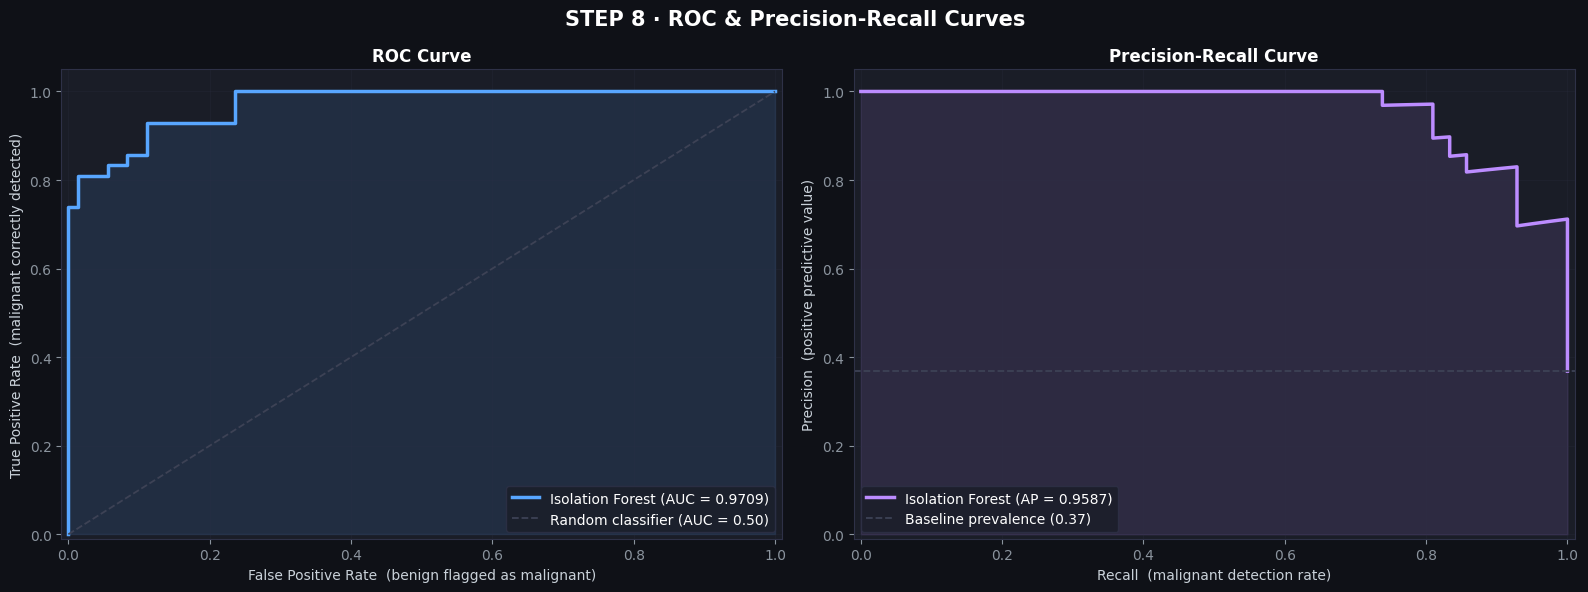

In [41]:
# ── VIZ 1: ROC & Precision-Recall Curves ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('STEP 8 · ROC & Precision-Recall Curves',
             fontsize=15, fontweight='bold', color='white')
 
ax = axes[0]
ax.plot(fpr_curve, tpr_curve, color=ACCENT, linewidth=2.5,
        label=f'Isolation Forest (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='#3d4255', linestyle='--',
        linewidth=1.3, label='Random classifier (AUC = 0.50)')
ax.fill_between(fpr_curve, tpr_curve, alpha=0.12, color=ACCENT)
ax.set_title('ROC Curve', fontweight='bold', color='white')
ax.set_xlabel('False Positive Rate  (benign flagged as malignant)')
ax.set_ylabel('True Positive Rate  (malignant correctly detected)')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3147', labelcolor='white')
ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
 
ax = axes[1]
ax.plot(rec_curve, prec_curve, color=PURPLE, linewidth=2.5,
        label=f'Isolation Forest (AP = {ap:.4f})')
ax.axhline(y_test.mean(), color='#3d4255', linestyle='--', linewidth=1.3,
           label=f'Baseline prevalence ({y_test.mean():.2f})')
ax.fill_between(rec_curve, prec_curve, alpha=0.12, color=PURPLE)
ax.set_title('Precision-Recall Curve', fontweight='bold', color='white')
ax.set_xlabel('Recall  (malignant detection rate)')
ax.set_ylabel('Precision  (positive predictive value)')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3147', labelcolor='white')
ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
 
plt.tight_layout()
plt.savefig('bc_step8_roc_pr.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
plt.close()
 


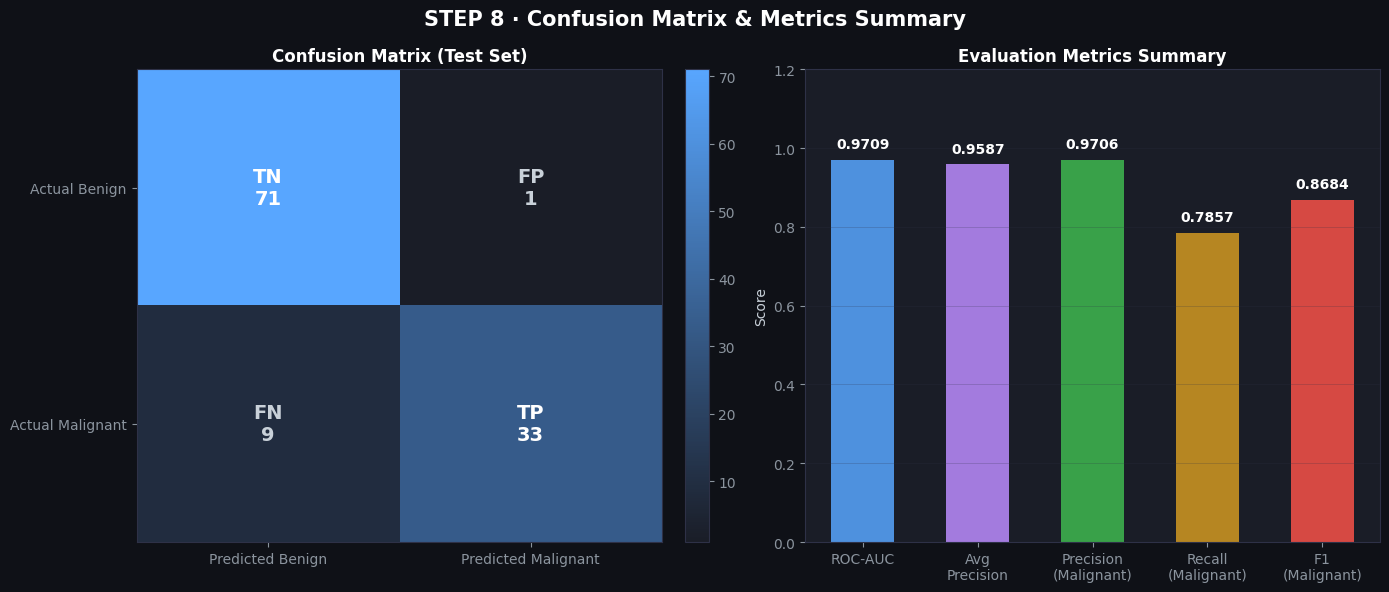

In [42]:
# ── VIZ 2: Confusion Matrix + Metrics Summary ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('STEP 8 · Confusion Matrix & Metrics Summary',
             fontsize=15, fontweight='bold', color='white')
 
ax = axes[0]
cmap2 = LinearSegmentedColormap.from_list('diag_cm', ['#1a1d27', ACCENT], N=256)
im = ax.imshow(cm, cmap=cmap2, aspect='auto')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted Benign', 'Predicted Malignant'], fontsize=10)
ax.set_yticklabels(['Actual Benign', 'Actual Malignant'], fontsize=10)
ax.set_title('Confusion Matrix (Test Set)', fontweight='bold', color='white')
cm_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_labels[i][j]}\n{cm[i, j]}',
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm[i, j] > cm.max() * 0.4 else '#c9d1d9')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
 
ax = axes[1]
metric_labels = {
    'ROC-AUC':                auc,
    'Avg\nPrecision':         ap,
    'Precision\n(Malignant)': precision_malignant,
    'Recall\n(Malignant)':    recall_malignant,
    'F1\n(Malignant)':        f1_malignant,
}
bars = ax.bar(list(metric_labels.keys()), list(metric_labels.values()),
              color=[ACCENT, PURPLE, BENIGN, WARN, MALIGNANT],
              alpha=0.85, width=0.55)
ax.set_title('Evaluation Metrics Summary', fontweight='bold', color='white')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.2)
for bar, val in zip(bars, metric_labels.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            f'{val:.4f}', ha='center', color='white',
            fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig('bc_step8_confusion.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
plt.close()


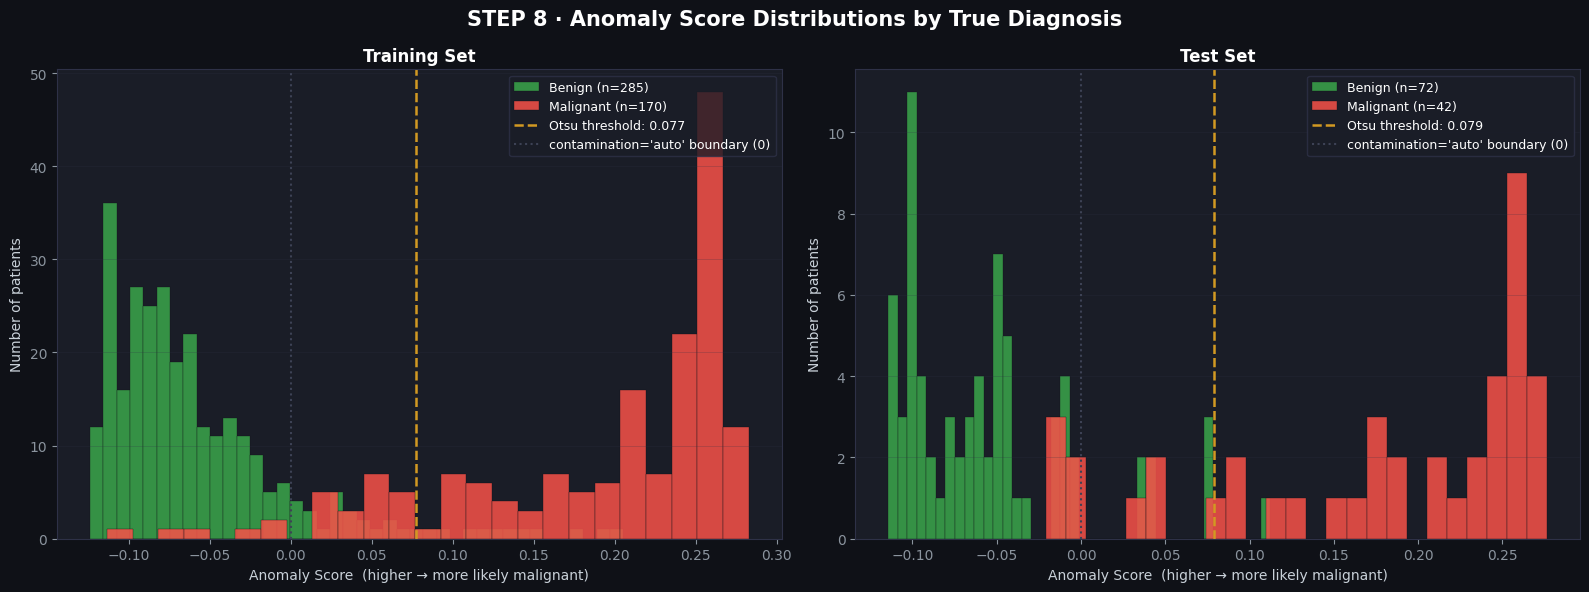

In [43]:
# ── VIZ 3: Anomaly Score Distributions by True Diagnosis ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('STEP 8 · Anomaly Score Distributions by True Diagnosis',
             fontsize=15, fontweight='bold', color='white')
 
for ax, scores, true_labels, title in [
    (axes[0], train_scores, y_train.values, 'Training Set'),
    (axes[1], test_scores,  y_test.values,  'Test Set'),
]:
    benign_scores    = scores[true_labels == 0]
    malignant_scores = scores[true_labels == 1]
    ax.hist(benign_scores, bins=40, color=BENIGN, alpha=0.75,
            label=f'Benign (n={len(benign_scores)})',
            edgecolor='#0f1117', linewidth=0.3)
    ax.hist(malignant_scores, bins=25, color=MALIGNANT, alpha=0.85,
            label=f'Malignant (n={len(malignant_scores)})',
            edgecolor='#0f1117', linewidth=0.3)
    # Threshold derived from score distribution — no label information used
    thresh = otsu_threshold(scores)
    ax.axvline(thresh, color=WARN, linestyle='--', linewidth=1.8,
               label=f'Otsu threshold: {thresh:.3f}')
    ax.axvline(0, color='#3d4255', linestyle=':', linewidth=1.5,
               label="contamination='auto' boundary (0)")
    ax.set_title(title, fontweight='bold', color='white')
    ax.set_xlabel('Anomaly Score  (higher → more likely malignant)')
    ax.set_ylabel('Number of patients')
    ax.legend(facecolor='#1a1d27', edgecolor='#2e3147',
              labelcolor='white', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig('bc_step8_scores.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
plt.close()


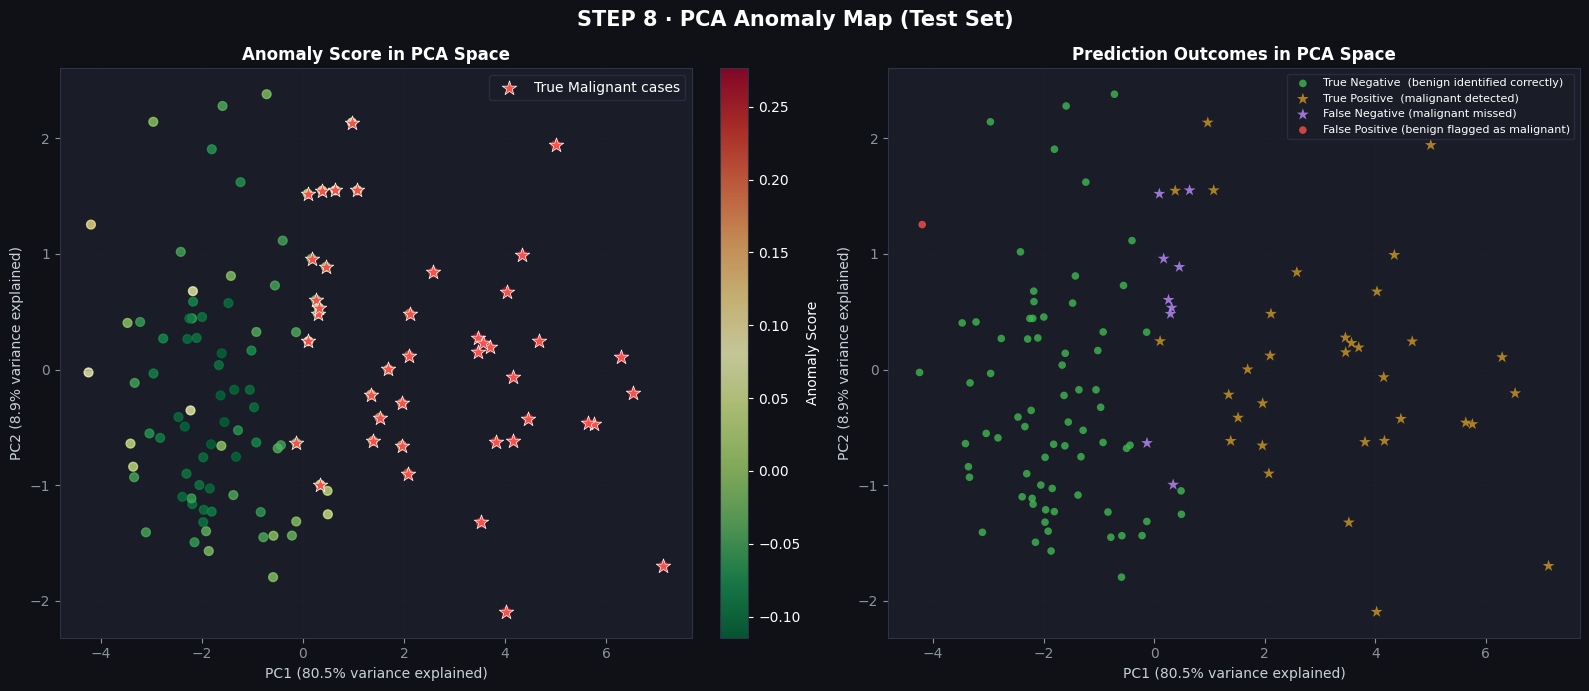

In [44]:
# ── VIZ 4: PCA Anomaly Map ──
pca = PCA(n_components=2, random_state=42)
pca.fit(X_scaled[selected_features])
X_test_pca = pca.transform(X_test_sel)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('STEP 8 · PCA Anomaly Map (Test Set)',
             fontsize=15, fontweight='bold', color='white')
 
# Colour points by anomaly score
ax = axes[0]
sc = ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                c=test_scores, cmap='RdYlGn_r', s=40, alpha=0.75)
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Anomaly Score', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')
malignant_idx = np.where(y_test.values == 1)[0]
ax.scatter(X_test_pca[malignant_idx, 0], X_test_pca[malignant_idx, 1],
           c=MALIGNANT, s=120, marker='*', zorder=5,
           edgecolors='white', linewidths=0.5,
           label='True Malignant cases')
ax.set_title('Anomaly Score in PCA Space', fontweight='bold', color='white')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3147', labelcolor='white')
ax.grid(alpha=0.2)
 
# Colour points by prediction outcome
ax = axes[1]
outcome_colors = {
    (0, 0): BENIGN,     # True Negative  — benign correctly identified
    (1, 1): WARN,       # True Positive  — malignant correctly detected
    (0, 1): MALIGNANT,  # False Positive — benign incorrectly flagged
    (1, 0): PURPLE,     # False Negative — malignant missed
}
outcome_labels = {
    (0, 0): 'True Negative  (benign identified correctly)',
    (1, 1): 'True Positive  (malignant detected)',
    (0, 1): 'False Positive (benign flagged as malignant)',
    (1, 0): 'False Negative (malignant missed)',
}
plotted = set()
for i in range(len(y_test)):
    outcome = (int(y_test.values[i]), int(test_pred[i]))
    lbl = outcome_labels[outcome] if outcome not in plotted else ''
    ax.scatter(X_test_pca[i, 0], X_test_pca[i, 1],
               c=outcome_colors[outcome],
               s=80 if outcome[0] == 1 else 30,
               marker='*' if outcome[0] == 1 else 'o',
               alpha=0.8, edgecolors='none',
               label=lbl, zorder=5 if outcome[0] == 1 else 3)
    plotted.add(outcome)
ax.set_title('Prediction Outcomes in PCA Space',
             fontweight='bold', color='white')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3147',
          labelcolor='white', fontsize=8)
ax.grid(alpha=0.2)
 
plt.tight_layout()
plt.savefig('bc_step8_pca.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
plt.close()
 

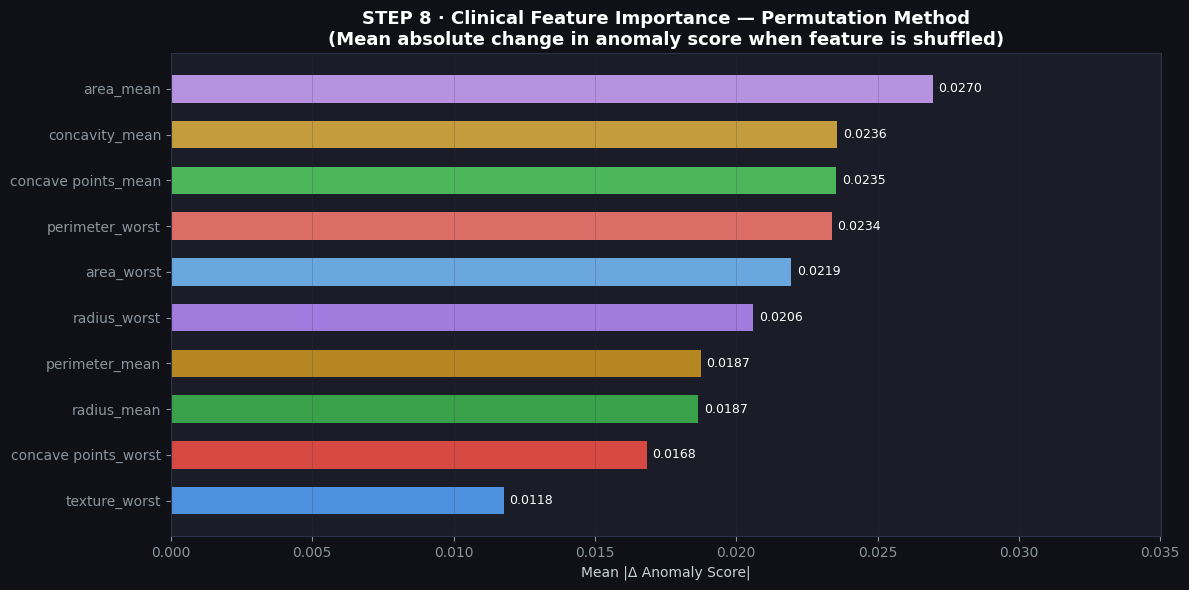

In [45]:
 #── VIZ 5: Permutation Feature Importance ──
np.random.seed(42)
baseline_scores    = -iso.decision_function(X_test_sel)
feature_importance = {}
for i, feat in enumerate(selected_features):
    X_permuted = X_test_sel.values.copy()
    np.random.shuffle(X_permuted[:, i])
    permuted_scores = -iso.decision_function(X_permuted)
    # Importance = how much anomaly scores change when this
    # feature's information is destroyed by shuffling
    feature_importance[feat] = float(
        np.mean(np.abs(permuted_scores - baseline_scores))
    )
fi_series = pd.Series(feature_importance).sort_values()
 
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f1117')
ax.barh(fi_series.index, fi_series.values,
        color=PALETTE[:len(fi_series)], alpha=0.85, height=0.6)
ax.set_title(
    'STEP 8 · Clinical Feature Importance — Permutation Method\n'
    '(Mean absolute change in anomaly score when feature is shuffled)',
    fontweight='bold', color='white', fontsize=13)
ax.set_xlabel('Mean |Δ Anomaly Score|')
for bar, val in zip(ax.patches, fi_series.values):
    ax.text(bar.get_width() + 0.0002,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', color='white', fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, fi_series.max() * 1.3)
 
plt.tight_layout()
plt.savefig('bc_step8_feat_imp.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
plt.close()


In [46]:
# ─────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  Dataset             : Breast Cancer Wisconsin (n=569)")
print(f"  Model               : Isolation Forest (fully unsupervised)")
print(f"  Training strategy   : Fitted on benign samples only")
print(f"  n_estimators        : 100")
print(f"  Contamination       : 'auto'  (threshold at score=0, no label use)")
print(f"  Decision threshold  : Otsu method on score distribution")
print(f"  Features selected   : {len(selected_features)}")
print(f"")
print(f"  PRIMARY METRIC (threshold-independent):")
print(f"  ROC-AUC             : {auc:.4f}")
print(f"  Average Precision   : {ap:.4f}")
print(f"")
print(f"  SECONDARY METRICS (at Otsu threshold):")
print(f"  Recall (Malignant)  : {recall_malignant:.4f}"
      f"  ← {tp} of {tp+fn} malignant cases detected")
print(f"  Precision(Malignant): {precision_malignant:.4f}"
      f"  ← {fp} benign cases incorrectly flagged")
print(f"  F1 (Malignant)      : {f1_malignant:.4f}")
print(f"")
print(f"  Confusion Matrix (Test Set, Otsu threshold):")
print(f"                    Predicted Benign   Predicted Malignant")
print(f"  Actual Benign         {tn:>4}               {fp:>4}")
print(f"  Actual Malignant      {fn:>4}               {tp:>4}")
print("=" * 60)
print(f"  Output plots:")
for plot_name in [
    'bc_step1_overview', 'bc_step3_distributions',
    'bc_step4_correlation', 'bc_step5_scaling_split',
    'bc_step6_rfe', 'bc_step7_score_dist',
    'bc_step8_roc_pr', 'bc_step8_confusion',
    'bc_step8_scores', 'bc_step8_pca', 'bc_step8_feat_imp',
]:
    print(f"    • {plot_name}.png")
print("=" * 60)
 


  FINAL RESULTS SUMMARY
  Dataset             : Breast Cancer Wisconsin (n=569)
  Model               : Isolation Forest (fully unsupervised)
  Training strategy   : Fitted on benign samples only
  n_estimators        : 100
  Contamination       : 'auto'  (threshold at score=0, no label use)
  Decision threshold  : Otsu method on score distribution
  Features selected   : 10

  PRIMARY METRIC (threshold-independent):
  ROC-AUC             : 0.9709
  Average Precision   : 0.9587

  SECONDARY METRICS (at Otsu threshold):
  Recall (Malignant)  : 0.7857  ← 33 of 42 malignant cases detected
  Precision(Malignant): 0.9706  ← 1 benign cases incorrectly flagged
  F1 (Malignant)      : 0.8684

  Confusion Matrix (Test Set, Otsu threshold):
                    Predicted Benign   Predicted Malignant
  Actual Benign           71                  1
  Actual Malignant         9                 33
  Output plots:
    • bc_step1_overview.png
    • bc_step3_distributions.png
    • bc_step4_correlation